Dataset Explanation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
file_path = "classification.csv"
df = pd.read_csv(file_path)

# Display dataset information and preview
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   hours_per_week_bin  48842 non-null  object
 1   occupation_bin      48842 non-null  object
 2   msr_bin             48842 non-null  object
 3   capital_gl_bin      48842 non-null  object
 4   race_sex_bin        48842 non-null  object
 5   education_num_bin   48842 non-null  object
 6   education_bin       48842 non-null  object
 7   workclass_bin       48842 non-null  object
 8   age_bin             48842 non-null  object
 9   flag                48842 non-null  object
 10  y                   48842 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 4.1+ MB


In [2]:
df.head()

,hours_per_week_bin,occupation_bin,msr_bin,capital_gl_bin,race_sex_bin,education_num_bin,education_bin,workclass_bin,age_bin,flag,y
0,b. 31-40,b. Mid - Low,b. Mid,c. > 0,c. High,c. 13,c. Bachelors,b. income,d. 36-40 & 56-60,train,0
1,a. 0-30,e. High,c. High,a. = 0,c. High,c. 13,c. Bachelors,b. income,e. 40-55,train,0
2,b. 31-40,a. Low,b. Mid,a. = 0,c. High,b. 9-12,b. Mid,b. income,d. 36-40 & 56-60,train,0
3,b. 31-40,a. Low,c. High,a. = 0,b. Mid,a. 0-8,a. Low,b. income,e. 40-55,train,0
4,b. 31-40,e. High,c. High,a. = 0,a. Low,c. 13,c. Bachelors,b. income,b. 26-30 & 71-100,train,0


**Dataset Explanation**

This dataset appears to be a binary classification dataset where the goal is to predict a categorical outcome (y) based on various demographic and economic factors.

**Dataset Structure**
1. Number of Rows: 48,842
2. Number of Columns: 11
3. Target Variable: y (Binary: 0 or 1)
4. Feature Variables (Categorical):
* hours_per_week_bin: Categorized work hours per week.
* occupation_bin: Grouped occupation levels.
* msr_bin: Economic or marital status classification.
* capital_gl_bin: Categorized capital gain/loss.
* race_sex_bin: Combined race and gender category.
* education_num_bin: Grouped education years.
* education_bin: Education level classification.
* workclass_bin: Type of work category.
* age_bin: Age grouped into bins.
* flag: Indicates training (train) or test (test) set.

Classification Tasks: The goal of the classification model (Logistic/Probit Regression) is to predict y, which is a binary label (0 or 1). What are we classifying? We are predicting whether an individual earns more than 50K per year based on demographic and work-related factors.

Data preparation

In [3]:
# Data Preparation
cat_feats = ['age_bin','capital_gl_bin','education_bin','hours_per_week_bin','msr_bin','occupation_bin','race_sex_bin']

# Split dataset into train and test
y_train = df[df['flag']=='train']['y']
x_train = df[df['flag']=='train'][cat_feats]
x_train = pd.get_dummies(x_train, columns=cat_feats, drop_first=True)

y_test = df[df['flag']=='test']['y']
x_test = df[df['flag']=='test'][cat_feats]
x_test = pd.get_dummies(x_test, columns=cat_feats, drop_first=True)

# Convert to numpy arrays
x_train, y_train = x_train.values, y_train.values
x_test, y_test = x_test.values, y_test.values

# Apply manual feature scaling
mean_train = np.mean(x_train, axis=0)
std_train = np.std(x_train, axis=0)
x_train_scaled = (x_train - mean_train) / std_train
x_test_scaled = (x_test - mean_train) / std_train

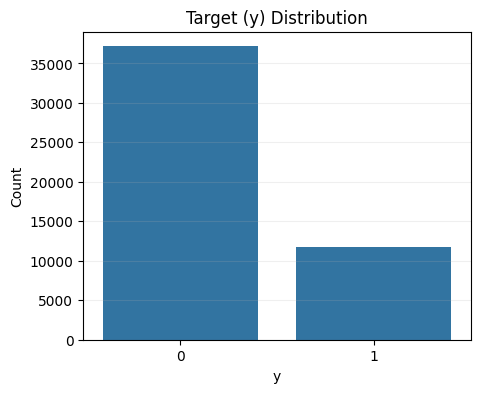

In [4]:
# 目標變數分布
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='y')
plt.title("Target (y) Distribution")
plt.xlabel("y")
plt.ylabel("Count")
plt.grid(axis='y', alpha=0.2)
plt.show()

Assignment

In [5]:
# Logistic Regression from Scratch
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=3000):
        self.lr = learning_rate
        self.iterations = iterations

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.iterations):
            linear_model = X @ self.w + self.b
            y_predicted = self._sigmoid(linear_model)

            dw = (1 / n_samples) * (X.T @ (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.lr * dw
            self.b -= self.lr * db
        

    def predict_proba(self, X):
        linear_model = X @ self.w + self.b
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

# Probit Regression from Scratch
class ProbitRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=3000):
        self.lr = learning_rate
        self.iterations = iterations

    def _probit(self, z):
        from scipy.stats import norm
        return norm.cdf(z)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.iterations):
            linear_model = X @ self.w + self.b
            y_predicted = self._probit(linear_model)

            error = y_predicted - y
            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        linear_model = X @ self.w + self.b
        return self._probit(linear_model)

    def predict(self, X, threshold=0.5):
        y_predicted_cls = [1 if i > threshold else 0 for i in self.predict_proba(X)]
        return np.array(y_predicted_cls)
    
# Compute Confusion Matrices
def compute_confusion_matrix(y_true, y_pred, verbose=True):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    cm = np.array([[TP, FN], 
                   [FP, TN]])

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
    
    if verbose:
        print("Confusion Matrix:")
        print(cm)
        print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
        print(f"Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F-Score: {f_score:.4f}")

        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Predict 1', 'Predict 0'], 
                    yticklabels=['Actual 1', 'Actual 0'])
        plt.title('Confusion Matrix Heatmap')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.show()
    
    return cm

# Compute ROC Curves and AUC
def compute_roc_curve(y_true, y_scores):
    thresholds = np.linspace(0, 1, num=100)
    fpr_list = []
    tpr_list = []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        cm = compute_confusion_matrix(y_true, y_pred, verbose=False)
        TP, FN, FP, TN = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
        
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
        
        fpr_list.append(fpr)
        tpr_list.append(tpr)

    return np.array(fpr_list), np.array(tpr_list)

def compute_auc(fpr, tpr):
    return np.abs(np.trapezoid(tpr, fpr))

### learning rate = 0.001, and iteration = 2000

Logistic Regression:
Confusion Matrix:
[[ 1976  1870]
 [ 2422 10013]]
TP: 1976, TN: 10013, FP: 2422, FN: 1870
Accuracy: 0.7364, Precision: 0.4493, Recall: 0.5138, F-Score: 0.4794


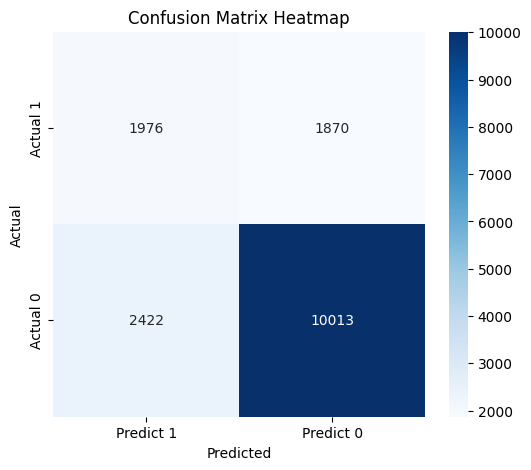

Probit Regression:
Confusion Matrix:
[[2237 1609]
 [2534 9901]]
TP: 2237, TN: 9901, FP: 2534, FN: 1609
Accuracy: 0.7455, Precision: 0.4689, Recall: 0.5816, F-Score: 0.5192


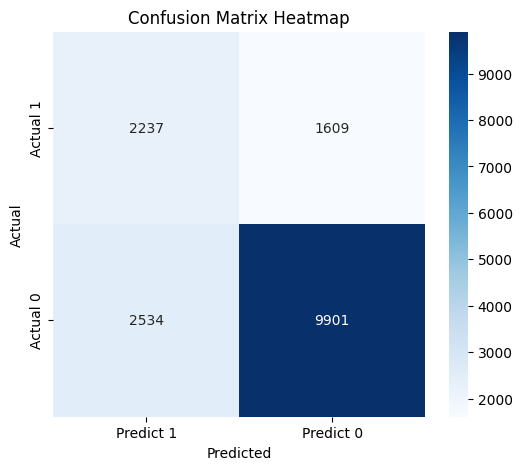

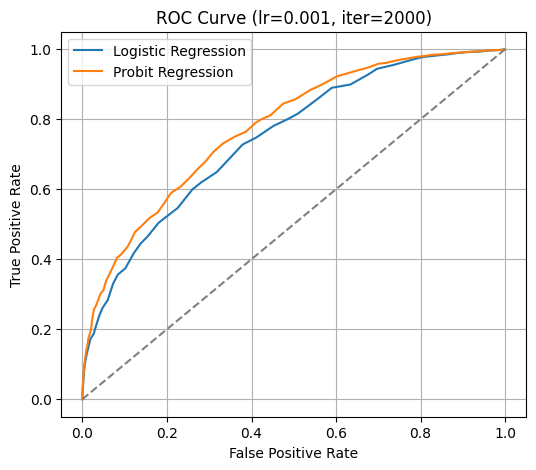

Logistic Regression AUC: 0.7462
Probit Regression AUC: 0.7771


In [6]:
# Train Models
lr_scratch = LogisticRegressionScratch(learning_rate=0.001, iterations=2000)
lr_scratch.fit(x_train, y_train)

pr_scratch = ProbitRegressionScratch(learning_rate=0.001, iterations=2000)
pr_scratch.fit(x_train, y_train)

# Predictions
y_pred_lr = lr_scratch.predict(x_test_scaled)
y_prob_lr = lr_scratch.predict_proba(x_test_scaled)

y_pred_pr = pr_scratch.predict(x_test_scaled)
y_prob_pr = pr_scratch.predict_proba(x_test_scaled)

# Compute Confusion Matrices
print("Logistic Regression:")
cm_lr = compute_confusion_matrix(y_test, y_pred_lr)
print("Probit Regression:")
cm_pr = compute_confusion_matrix(y_test, y_pred_pr)

# Compute ROC Curves
fpr_lr, tpr_lr = compute_roc_curve(y_test, y_prob_lr)
fpr_pr, tpr_pr = compute_roc_curve(y_test, y_prob_pr)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_pr, tpr_pr, label='Probit Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve (lr=0.001, iter=2000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()
plt.show()

# Compute AUC
auc_lr = compute_auc(fpr_lr, tpr_lr)
auc_pr = compute_auc(fpr_pr, tpr_pr)
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Probit Regression AUC: {auc_pr:.4f}")

### learning rate = 0.00001, and iteration = 6000

Logistic Regression:
Confusion Matrix:
[[ 1355  2491]
 [ 2288 10147]]
TP: 1355, TN: 10147, FP: 2288, FN: 2491
Accuracy: 0.7065, Precision: 0.3719, Recall: 0.3523, F-Score: 0.3619


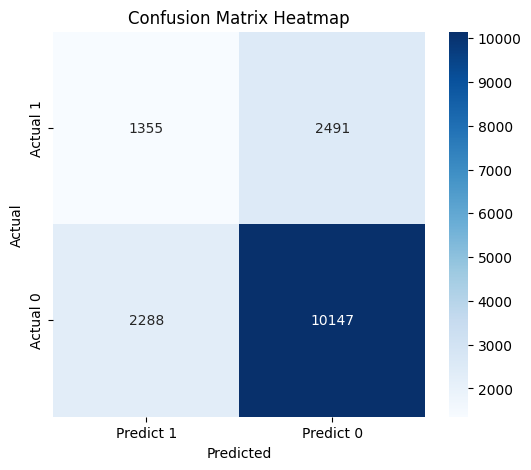

Probit Regression:
Confusion Matrix:
[[ 1419  2427]
 [ 2314 10121]]
TP: 1419, TN: 10121, FP: 2314, FN: 2427
Accuracy: 0.7088, Precision: 0.3801, Recall: 0.3690, F-Score: 0.3745


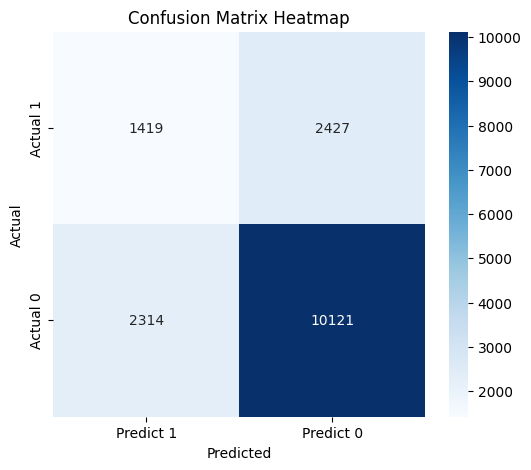

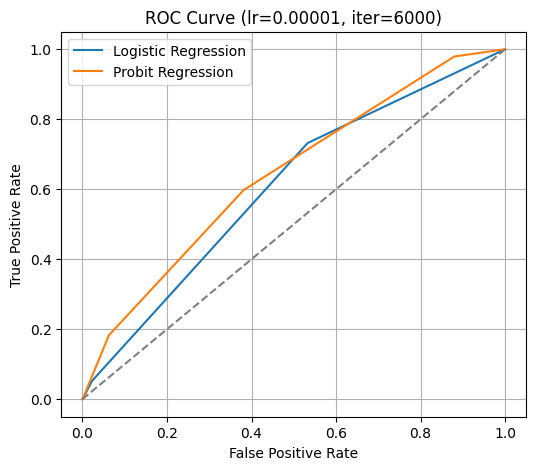

Logistic Regression AUC: 0.6052
Probit Regression AUC: 0.6420


In [7]:
# Train Models
lr_scratch = LogisticRegressionScratch(learning_rate=0.00001, iterations=6000)
lr_scratch.fit(x_train, y_train)

pr_scratch = ProbitRegressionScratch(learning_rate=0.00001, iterations=6000)
pr_scratch.fit(x_train, y_train)

# Predictions
y_pred_lr = lr_scratch.predict(x_test_scaled)
y_prob_lr = lr_scratch.predict_proba(x_test_scaled)

y_pred_pr = pr_scratch.predict(x_test_scaled)
y_prob_pr = pr_scratch.predict_proba(x_test_scaled)

# Compute Confusion Matrices
print("Logistic Regression:")
cm_lr = compute_confusion_matrix(y_test, y_pred_lr)
print("Probit Regression:")
cm_pr = compute_confusion_matrix(y_test, y_pred_pr)

# Compute ROC Curves
fpr_lr, tpr_lr = compute_roc_curve(y_test, y_prob_lr)
fpr_pr, tpr_pr = compute_roc_curve(y_test, y_prob_pr)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_pr, tpr_pr, label='Probit Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve (lr=0.00001, iter=6000)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()
plt.show()

# Compute AUC
auc_lr = compute_auc(fpr_lr, tpr_lr)
auc_pr = compute_auc(fpr_pr, tpr_pr)
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Probit Regression AUC: {auc_pr:.4f}")

### learning rate = 0.0001, and iteration = 1500

Logistic Regression:
Confusion Matrix:
[[ 1480  2366]
 [ 2345 10090]]
TP: 1480, TN: 10090, FP: 2345, FN: 2366
Accuracy: 0.7106, Precision: 0.3869, Recall: 0.3848, F-Score: 0.3859


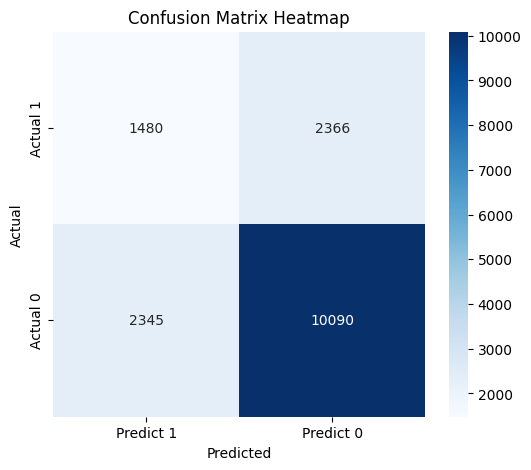

Probit Regression:
Confusion Matrix:
[[ 1496  2350]
 [ 2335 10100]]
TP: 1496, TN: 10100, FP: 2335, FN: 2350
Accuracy: 0.7122, Precision: 0.3905, Recall: 0.3890, F-Score: 0.3897


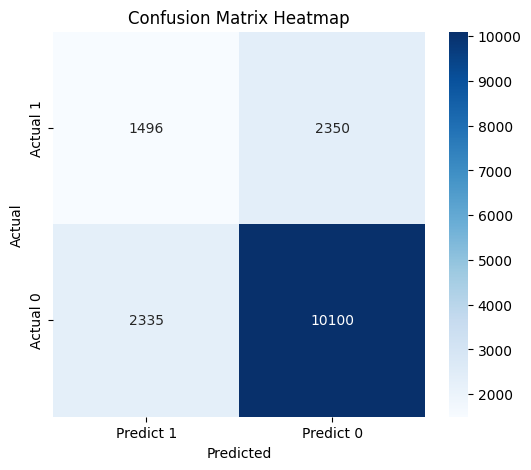

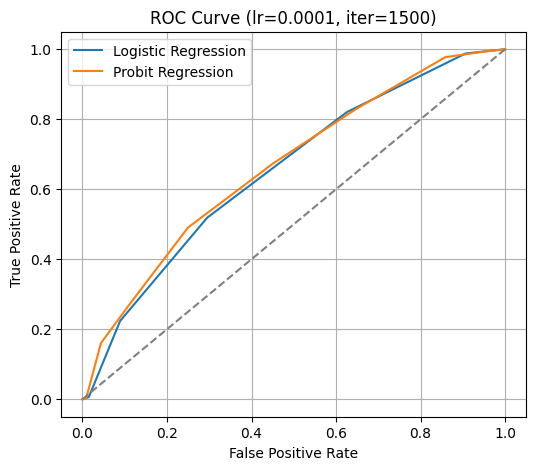

Logistic Regression AUC: 0.6531
Probit Regression AUC: 0.6655


In [8]:
# Train Models
lr_scratch = LogisticRegressionScratch(learning_rate=0.0001, iterations=1500)
lr_scratch.fit(x_train, y_train)

pr_scratch = ProbitRegressionScratch(learning_rate=0.0001, iterations=1500)
pr_scratch.fit(x_train, y_train)

# Predictions
y_pred_lr = lr_scratch.predict(x_test_scaled)
y_prob_lr = lr_scratch.predict_proba(x_test_scaled)

y_pred_pr = pr_scratch.predict(x_test_scaled)
y_prob_pr = pr_scratch.predict_proba(x_test_scaled)

# Compute Confusion Matrices
print("Logistic Regression:")
cm_lr = compute_confusion_matrix(y_test, y_pred_lr)
print("Probit Regression:")
cm_pr = compute_confusion_matrix(y_test, y_pred_pr)

# Compute ROC Curves
fpr_lr, tpr_lr = compute_roc_curve(y_test, y_prob_lr)
fpr_pr, tpr_pr = compute_roc_curve(y_test, y_prob_pr)
plt.figure(figsize=(6, 5))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_pr, tpr_pr, label='Probit Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve (lr=0.0001, iter=1500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid()
plt.legend()
plt.show()

# Compute AUC
auc_lr = compute_auc(fpr_lr, tpr_lr)
auc_pr = compute_auc(fpr_pr, tpr_pr)
print(f"Logistic Regression AUC: {auc_lr:.4f}")
print(f"Probit Regression AUC: {auc_pr:.4f}")